# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The FIFA 2026 Player Performance Dataset](https://www.kaggle.com/datasets/debayank2024/fifa-2026-player-performance)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('fifa2026_player_performance_clean.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,player_name,nationality,club,position,age,market_value_eur_m,season,competition,match_id,minutes_played,...,assists,shots_on_target,pass_accuracy_pct,tackles,distance_covered_km,match_rating,yellow_card,red_card,fouls_committed,injured_flag
0,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,11.01,2025/26,Champions League,111378,53,...,0,0,NaN,2,5.79,5.8,False,False,0,False
1,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.69,2025/26,Champions League,111379,63,...,0,0,85.2,2,10.31,6.9,False,False,3,False
2,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.61,2025/26,Champions League,111380,90,...,0,0,94.8,4,14.50,7.5,False,False,0,False
3,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,11.26,2025/26,Champions League,111381,12,...,0,0,74.9,1,0.91,4.0,False,False,3,False
4,Achraf Hakimi,Morocco,Paris Saint-Germain,RB,21,10.50,2025/26,Champions League,111382,39,...,0,0,78.0,3,4.36,5.0,False,False,2,False


## last Five row

In [4]:
df.tail()

,player_name,nationality,club,position,age,market_value_eur_m,season,competition,match_id,minutes_played,...,assists,shots_on_target,pass_accuracy_pct,tackles,distance_covered_km,match_rating,yellow_card,red_card,fouls_committed,injured_flag
13392,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,25.30,2025/26,World Cup Qualifiers,111632,71,...,0,0,71.1,1,5.52,5.9,False,False,2,False
13393,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,NaN,2025/26,World Cup Qualifiers,111633,6,...,0,1,67.8,0,0.53,4.0,False,False,2,False
13394,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,26.48,2025/26,World Cup Qualifiers,111634,20,...,0,1,49.1,2,0.69,4.0,False,False,0,False
13395,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,25.89,2025/26,World Cup Qualifiers,111635,59,...,0,0,46.8,1,6.37,5.7,False,False,0,False
13396,Yves Bissouma,Mali,Tottenham Hotspur,CDM,39,24.40,2025/26,World Cup Qualifiers,111636,59,...,0,0,86.2,1,4.63,5.4,False,False,1,False


## Shape of our dataset

In [5]:
df.shape

(13397, 21)

## List out all columns

In [6]:
df.columns

Index(['player_name', 'nationality', 'club', 'position', 'age',
       'market_value_eur_m', 'season', 'competition', 'match_id',
       'minutes_played', 'goals', 'assists', 'shots_on_target',
       'pass_accuracy_pct', 'tackles', 'distance_covered_km', 'match_rating',
       'yellow_card', 'red_card', 'fouls_committed', 'injured_flag'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

player_name             object
nationality             object
club                    object
position                object
age                      int64
market_value_eur_m     float64
season                  object
competition             object
match_id                 int64
minutes_played           int64
goals                    int64
assists                  int64
shots_on_target          int64
pass_accuracy_pct      float64
tackles                  int64
distance_covered_km    float64
match_rating           float64
yellow_card               bool
red_card                  bool
fouls_committed          int64
injured_flag              bool
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13397 entries, 0 to 13396
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_name          13397 non-null  object 
 1   nationality          13397 non-null  object 
 2   club                 13397 non-null  object 
 3   position             13397 non-null  object 
 4   age                  13397 non-null  int64  
 5   market_value_eur_m   13127 non-null  float64
 6   season               13397 non-null  object 
 7   competition          13397 non-null  object 
 8   match_id             13397 non-null  int64  
 9   minutes_played       13397 non-null  int64  
 10  goals                13397 non-null  int64  
 11  assists              13397 non-null  int64  
 12  shots_on_target      13397 non-null  int64  
 13  pass_accuracy_pct    12590 non-null  float64
 14  tackles              13397 non-null  int64  
 15  distance_covered_km  12718 non-null 

## Check Null Value

In [9]:
df.isnull().sum()

player_name              0
nationality              0
club                     0
position                 0
age                      0
market_value_eur_m     270
season                   0
competition              0
match_id                 0
minutes_played           0
goals                    0
assists                  0
shots_on_target          0
pass_accuracy_pct      807
tackles                  0
distance_covered_km    679
match_rating             0
yellow_card              0
red_card                 0
fouls_committed          0
injured_flag             0
dtype: int64

## Drop Null and Constant Feachers

In [10]:
df.drop(columns=['market_value_eur_m', 'pass_accuracy_pct', 'distance_covered_km', 'season'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,age,match_id,minutes_played,goals,assists,shots_on_target,tackles,match_rating,fouls_committed
count,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000,13397.000000
mean,28.273569,106698.000000,59.996716,0.164813,0.127566,0.292006,0.980817,6.121983,1.297529
std,6.435837,3867.525113,27.647981,0.440731,0.369907,0.621698,1.363312,1.231560,1.144203
min,17.000000,100000.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,23.000000,103349.000000,38.000000,0.000000,0.000000,0.000000,0.000000,5.200000,0.000000
50%,28.000000,106698.000000,67.000000,0.000000,0.000000,0.000000,0.000000,6.200000,1.000000
75%,34.000000,110047.000000,86.000000,0.000000,0.000000,0.000000,1.000000,7.000000,2.000000
max,39.000000,113396.000000,90.000000,4.000000,3.000000,6.000000,10.000000,10.000000,9.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

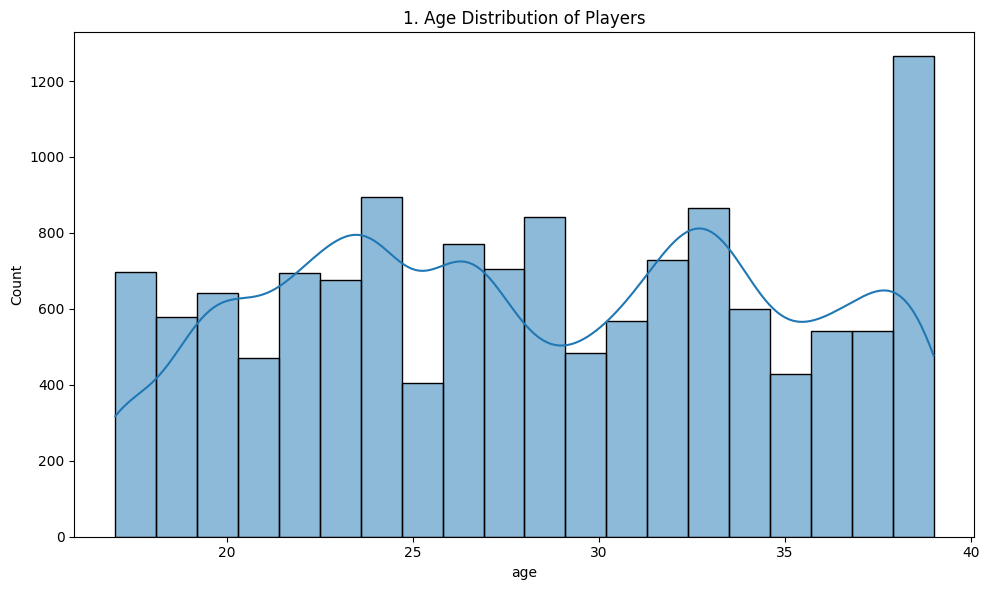

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Players')
show_fig()
plot_no += 1

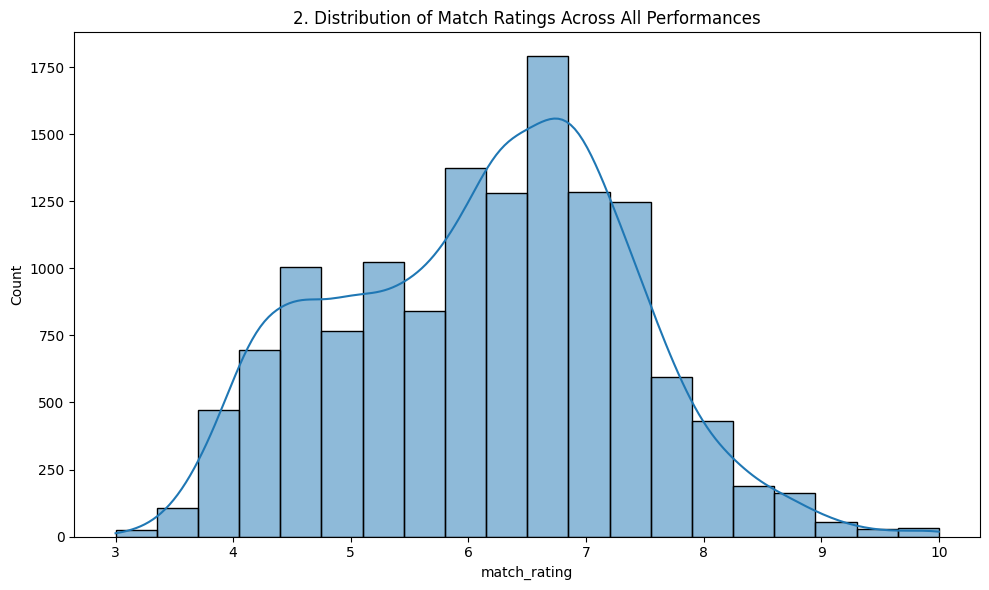

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='match_rating', bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Match Ratings Across All Performances')
show_fig()
plot_no += 1

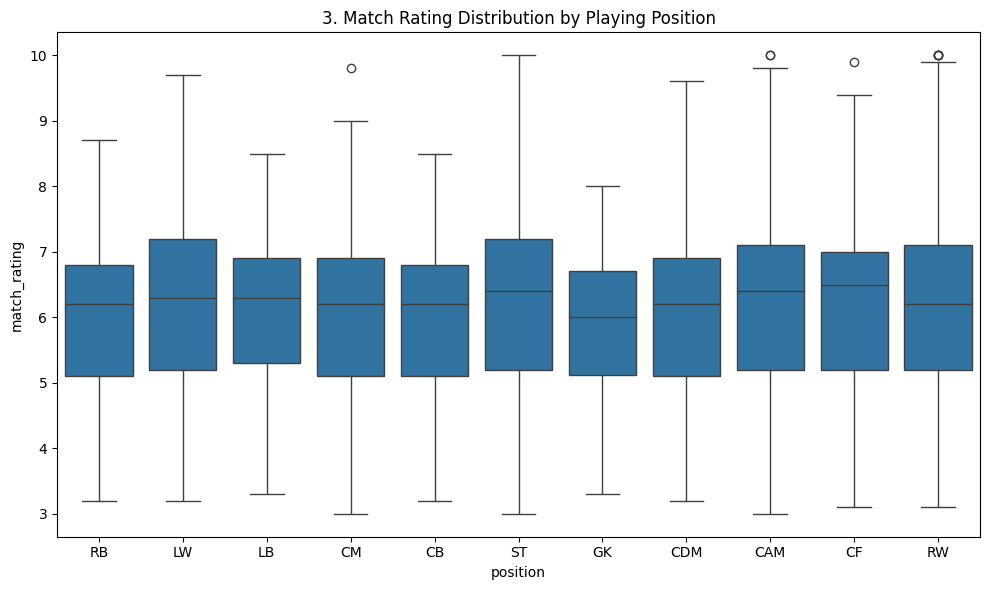

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='position', y='match_rating')
plt.title(f'{plot_no}. Match Rating Distribution by Playing Position')
show_fig()
plot_no += 1

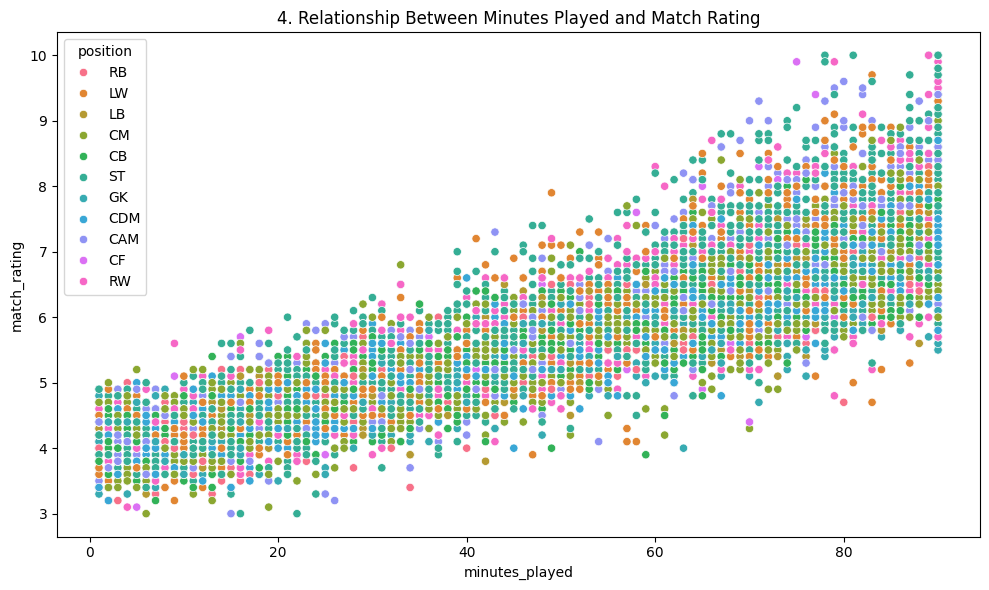

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='minutes_played', y='match_rating', hue='position')
plt.title(f'{plot_no}. Relationship Between Minutes Played and Match Rating')
show_fig()
plot_no += 1

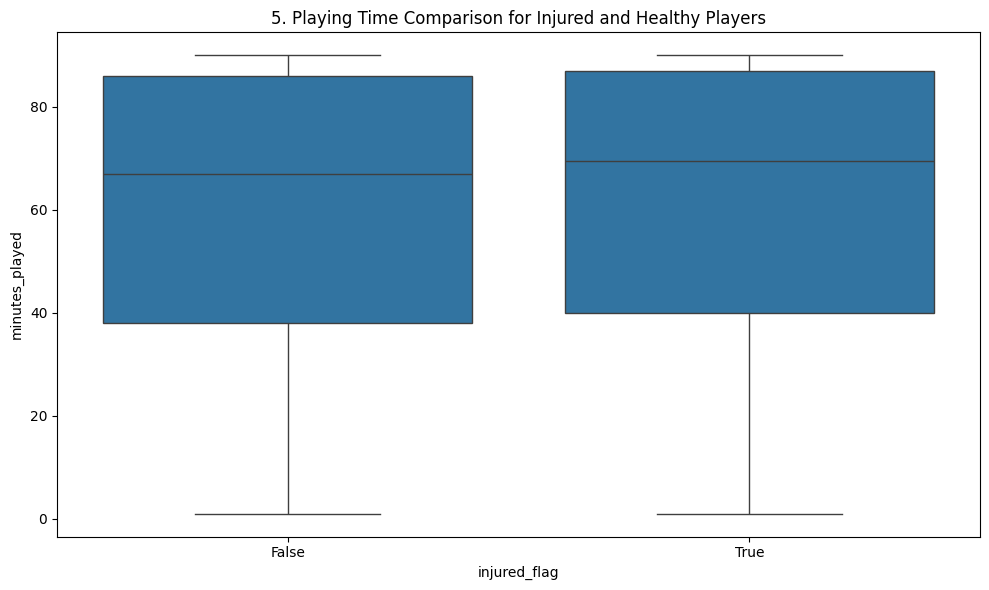

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='injured_flag', y='minutes_played')
plt.title(f'{plot_no}. Playing Time Comparison for Injured and Healthy Players')
show_fig()
plot_no += 1

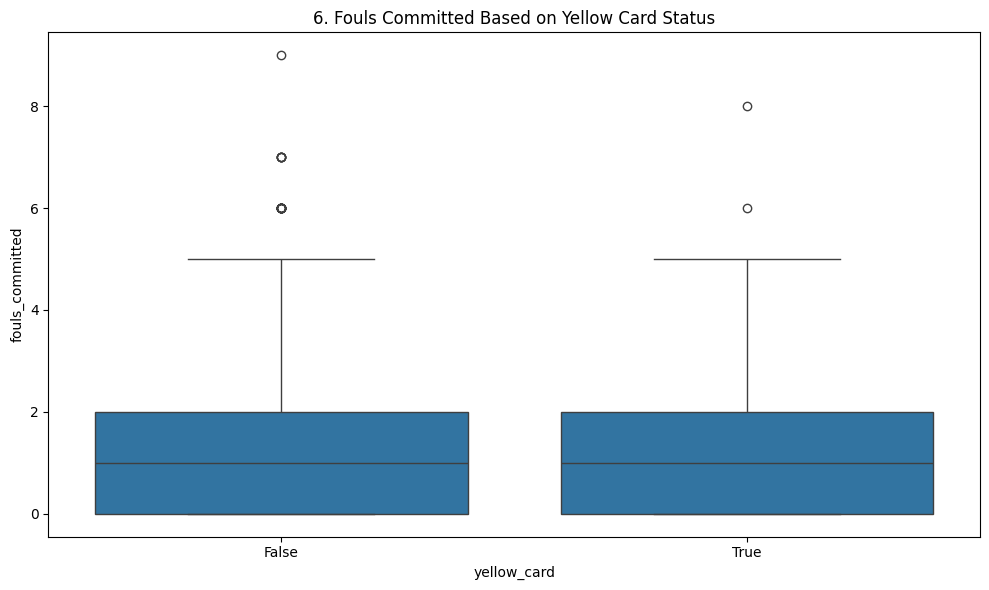

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='yellow_card', y='fouls_committed')
plt.title(f'{plot_no}. Fouls Committed Based on Yellow Card Status')
show_fig()
plot_no += 1

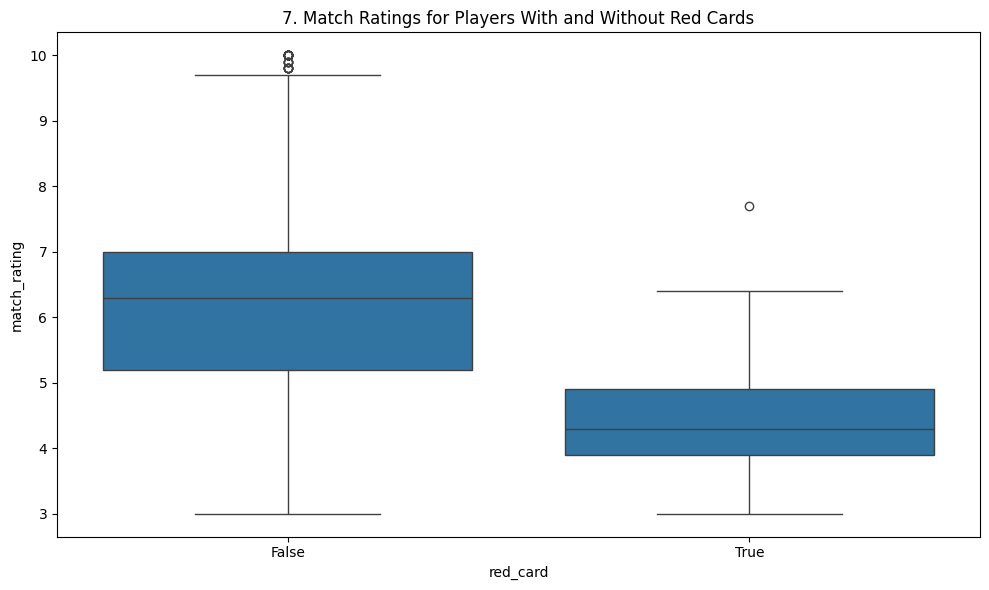

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='red_card', y='match_rating')
plt.title(f'{plot_no}. Match Ratings for Players With and Without Red Cards')
show_fig()
plot_no += 1

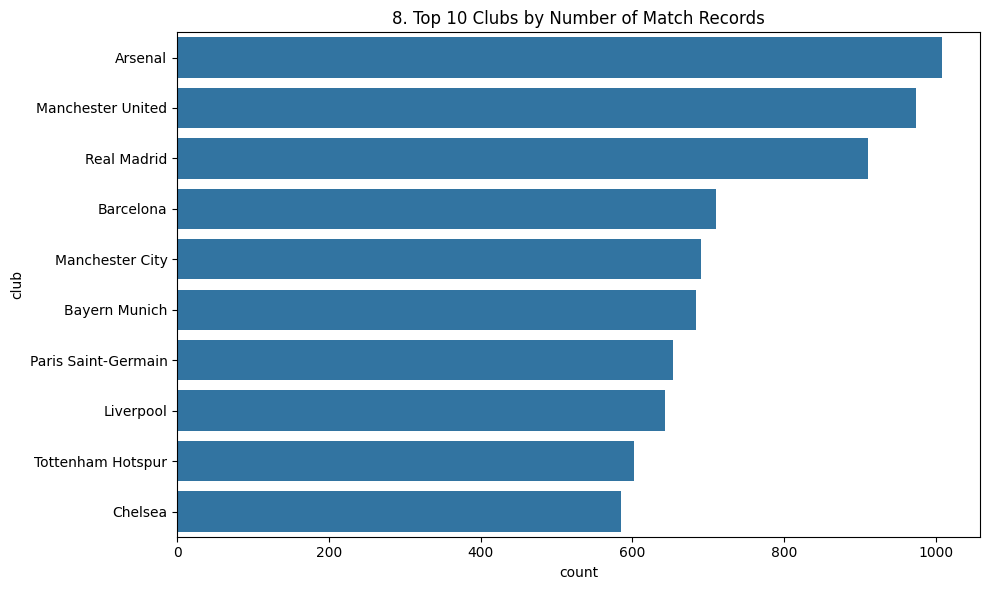

In [21]:
fig = plt.figure(figsize=(10,6))
top_clubs = df['club'].value_counts().head(10).index
sns.countplot(data=df[df['club'].isin(top_clubs)], y='club', order=top_clubs)
plt.title(f'{plot_no}. Top 10 Clubs by Number of Match Records')
show_fig()
plot_no += 1

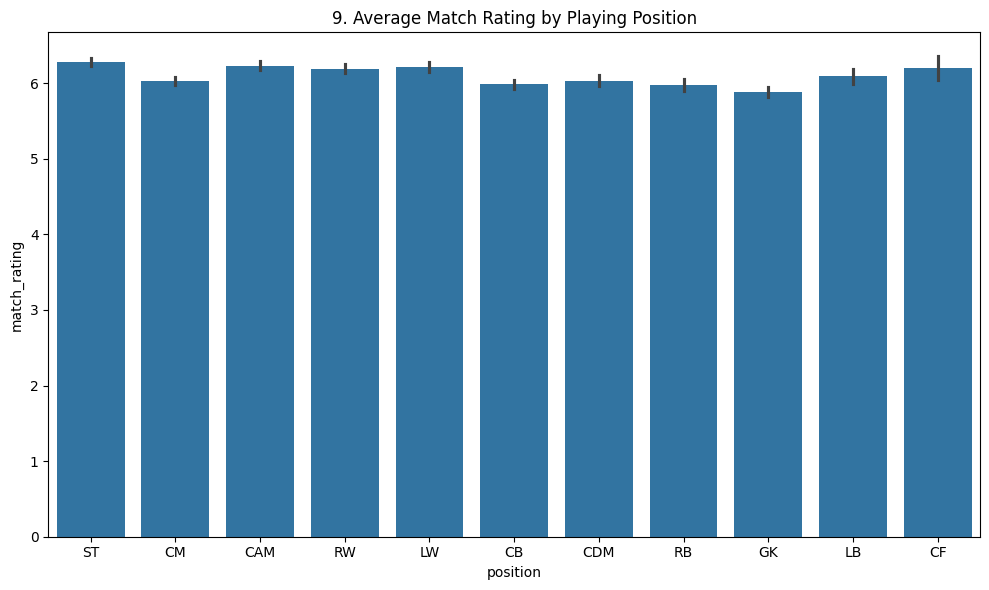

In [22]:
fig = plt.figure(figsize=(10,6))
top_positions = df['position'].value_counts().index
sns.barplot(data=df, x='position', y='match_rating', estimator='mean', order=top_positions)
plt.title(f'{plot_no}. Average Match Rating by Playing Position')
show_fig()
plot_no += 1

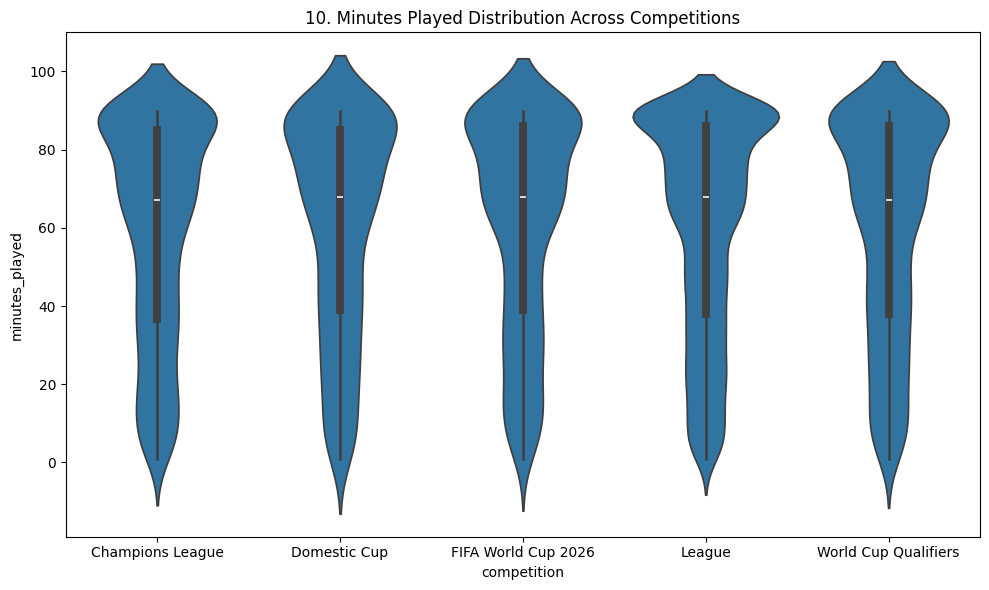

In [23]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='competition', y='minutes_played')
plt.title(f'{plot_no}. Minutes Played Distribution Across Competitions')
show_fig()
plot_no += 1

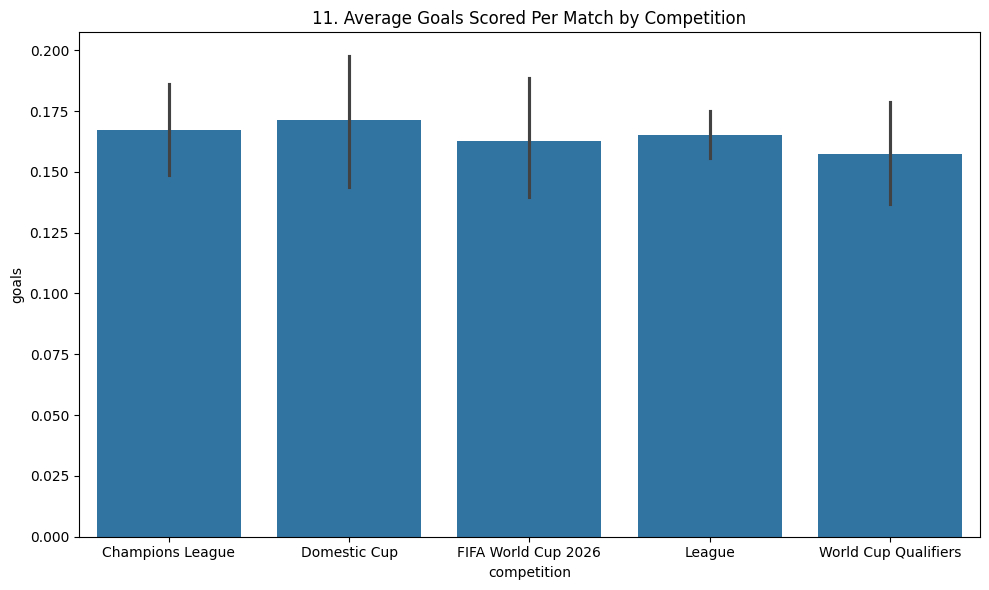

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='competition', y='goals', estimator='mean')
plt.title(f'{plot_no}. Average Goals Scored Per Match by Competition')
show_fig()
plot_no += 1

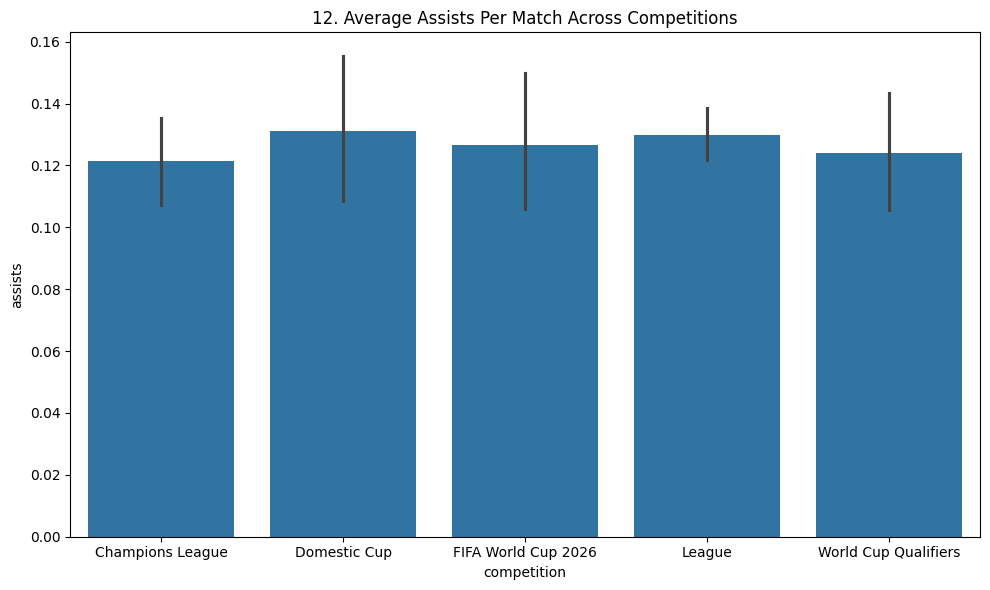

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='competition', y='assists', estimator='mean')
plt.title(f'{plot_no}. Average Assists Per Match Across Competitions')
show_fig()
plot_no += 1

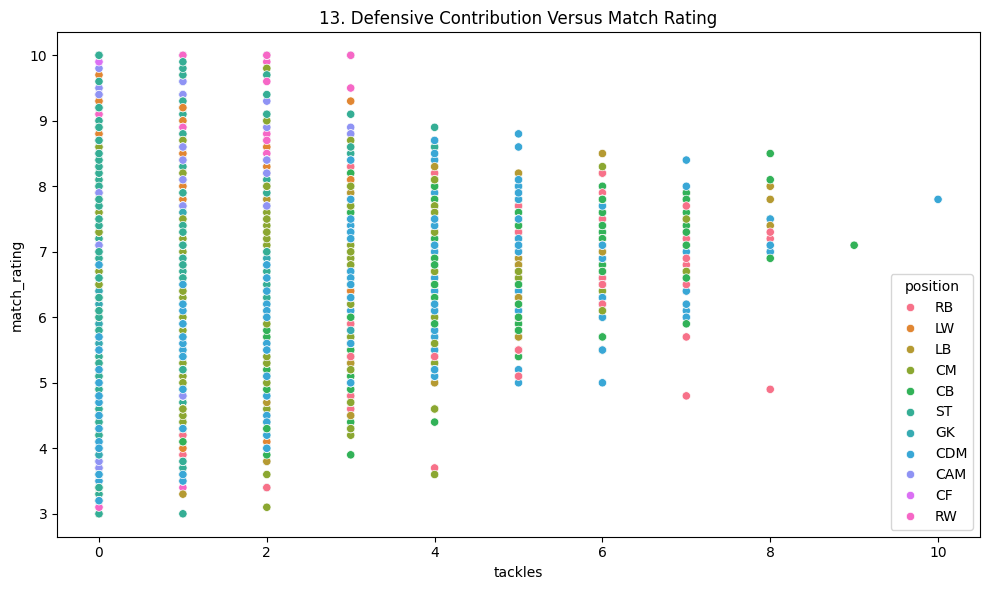

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tackles', y='match_rating', hue='position')
plt.title(f'{plot_no}. Defensive Contribution Versus Match Rating')
show_fig()
plot_no += 1

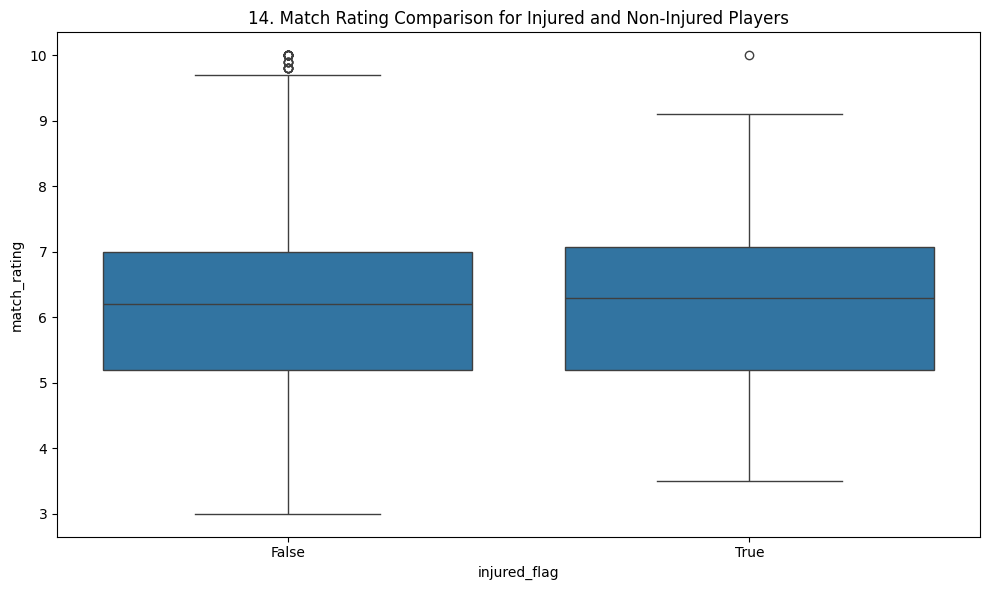

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='injured_flag', y='match_rating')
plt.title(f'{plot_no}. Match Rating Comparison for Injured and Non-Injured Players')
show_fig()
plot_no += 1

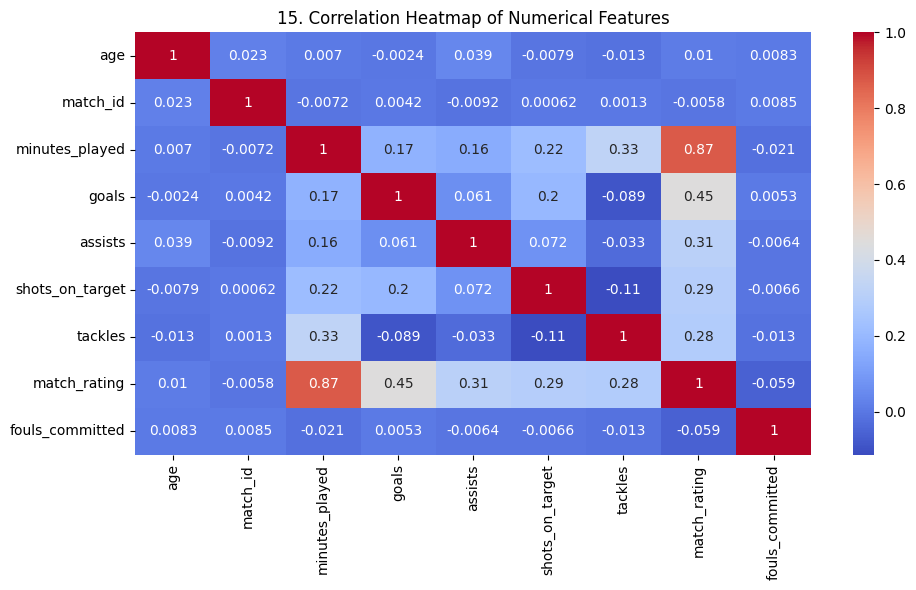

In [28]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Select input features

In [29]:
X = df[['age',
        'minutes_played',
        'goals',
        'assists',
        'shots_on_target',
        'tackles',
        'fouls_committed']]

## Select target feature

In [30]:
y = df['assists']

## Split the dataset

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Scale the features

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Create the SVM model

In [33]:
model = SVC(kernel='rbf', C=1.0, gamma='scale')

## Train the model

In [34]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Predict on the test data

In [35]:
y_pred = model.predict(X_test)

## Print model accuracy

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy : {accuracy:.4f}")

Model Accuracy : 1.0000


## Create confusion matrix and plot it

<Figure size 600x500 with 0 Axes>

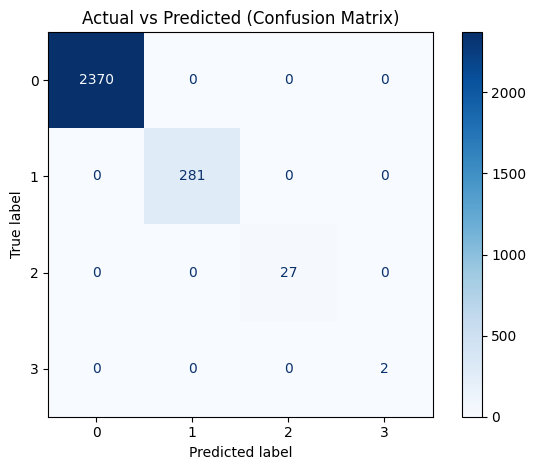

In [37]:
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues', values_format='d')
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()